# Koopman Operator Training with Autoencoder

This notebook implements a training pipeline for a Koopman operator model combined with an autoencoder. The code includes data loading, model definition, training, and visualization of results such as trajectories and eigenvalues.


In [1]:
import argparse
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Dataset
import torch.nn.init as init
import torch.multiprocessing as mp

# Import local modules (assuming these are available in your environment)
from utils.tools import set_seed, get_device
from utils.config_args import get_args
from utils.Viz import *
from KoopmanTrainer import Trainer
from data_handler import KoopmanDataHandler
from models.autoencoder import AutoEncoder
from models.koopman_operator import Knet

# Set multiprocessing start method
try:
    mp.set_start_method('spawn')
except RuntimeError:
    pass  # method already set

# Disable deterministic algorithms for flexibility
torch.use_deterministic_algorithms(False)

## Training Settings

Configure the training settings, including random seeds for reproducibility and device selection (CUDA or CPU).

In [2]:
# Get arguments (assuming get_args() handles command-line or default args)
args = get_args()

# Set seeds for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.cuda.manual_seed(args.seed)
torch.manual_seed(args.seed)
np.random.seed(args.seed)
set_seed(args.seed)

# Device configuration
device = get_device()

Using the CPU


In [ ]:
# editing the args 
args.dataset = 'discrete_spectrum'
args.folder = 'test'
# args.num_combinations
# args.num_samples
# args.time_steps
# args.max_time
# args.lr
# args.batch_size
# args.decoder_loss_weight
# args.bottleneck
# args.encoder_hidden_layers


## Create Experiment Folder

Set up the folder structure to save experiment results, including arguments in a JSON file.

In [ ]:
# Create experiment folder
experiment_folder = 'experiments'
if not os.path.isdir(experiment_folder):
    os.mkdir(experiment_folder)

folder_path = os.path.join(experiment_folder, args.folder)
os.makedirs(folder_path, exist_ok=True)

# Save arguments to JSON
args_dict = vars(args)
with open(os.path.join(folder_path, 'args.json'), 'w') as f:
    json.dump(args_dict, f,indent=2)

## Load and Prepare Dataset

Load and preprocess the dataset using the `KoopmanDataHandler` class, then create data loaders for training, validation, and testing.

In [ ]:
# Configuration for data handler
config = {
    "dataset": args.dataset,
    "data_dir": args.data_dir,
    "train_size": args.train_size,
    "val_size": args.val_size,
    "batch_size": args.batch_size,
    "noise": args.noise,
    "orthogonal_projection": args.orthogonal_projection,
    "num_combinations": args.num_combinations,
    "num_samples": args.num_samples,
    "time_steps": args.time_steps,
    "max_time": args.max_time,
    "normalize": args.normalize,
    "prediction_length": args.prediction_length,
    "stride": args.stride,
    "device": device,
    "theta": args.theta
}

# Initialize and prepare data
data_handler = KoopmanDataHandler(config)
data_handler.load_data()
preprocessed_data = data_handler.preprocess()
dataloaders = data_handler.create_dataloaders()

train_loader = dataloaders["train"]
val_loader = dataloaders["val"]
test_loader = dataloaders["test"]

# Get input size for model
input_size = preprocessed_data['Xtrain'].shape[-1]

100%|██████████| 5000/5000 [00:00<00:00, 31339.74it/s]

the shape of the data is torch.Size([5000, 51, 2])
Processing dataset: discrete_spectrum
train_idx: 4000, val_idx: 4500
Processed data shapes - Train: torch.Size([4000, 51, 2]), Val: torch.Size([500, 51, 2]), Test: torch.Size([500, 51, 2])



/Users/mohammedahmed/Desktop/Project/KoopKAN/Testing Multiple Repos/bio-koopman-autoencoder/data_handler.py:131: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Xtrain = torch.tensor(Xtrain, dtype=torch.float32).to(self.device)
/Users/mohammedahmed/Desktop/Project/KoopKAN/Testing Multiple Repos/bio-koopman-autoencoder/data_handler.py:132: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Xval = torch.tensor(Xval, dtype=torch.float32).to(self.device)
/Users/mohammedahmed/Desktop/Project/KoopKAN/Testing Multiple Repos/bio-koopman-autoencoder/data_handler.py:133: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().

## Model Definition

Define the autoencoder (`AutoEncoder`) and Koopman operator (`Knet`), then combine them into a `ModuleDict`.

In [8]:
# Define autoencoder and Koopman operator
ae = AutoEncoder(
    input_size=input_size,
    encoded_size=args.bottleneck,
    encoder_hidden_layers=args.encoder_hidden_layers,
    decoder_hidden_layers=args.decoder_hidden_layers,
    network_type=args.network_type,
    batch_norm=False
)
knet = Knet(size=args.bottleneck)

# Combine into a model
model = torch.nn.ModuleDict({'ae': ae, 'knet': knet})
model = model.to(device)

## Model Summary

Display the total number of parameters and the model architecture.

In [9]:
print('**** Setup ****')
print('Total params: %.2fM' % (sum(p.numel() for p in model.parameters())/1000000.0))
print('Total params: %.2fk' % (sum(p.numel() for p in model.parameters())/1000.0))
print('************')

print('**** Model Architecture ****')
print(model)
print('***************************')

**** Setup ****
Total params: 0.03M
Total params: 33.35k
************
**** Model Architecture ****
ModuleDict(
  (ae): AutoEncoder(
    (encoder): MLP(
      (net): ModuleList(
        (0): Linear(in_features=2, out_features=100, bias=True)
        (1): ReLU()
        (2): Linear(in_features=100, out_features=100, bias=True)
        (3): ReLU()
        (4): Linear(in_features=100, out_features=50, bias=True)
      )
    )
    (decoder): MLP(
      (net): ModuleList(
        (0): Linear(in_features=50, out_features=100, bias=True)
        (1): ReLU()
        (2): Linear(in_features=100, out_features=100, bias=True)
        (3): ReLU()
        (4): Linear(in_features=100, out_features=2, bias=True)
      )
    )
  )
  (knet): Knet(
    (net): Linear(in_features=50, out_features=50, bias=False)
  )
)
***************************


## Load from Checkpoint

Optionally load a pre-trained model from a checkpoint if specified.

In [10]:
if args.load_from_checkpoint:
    checkpoint_path = os.path.join(folder_path, 'model.pkl')
    if os.path.isfile(checkpoint_path):
        model.load_state_dict(torch.load(checkpoint_path))
        print(f'Model loaded from {checkpoint_path}')
    else:
        print(f'No checkpoint found at {checkpoint_path}')

## Training

Train the model using the `Trainer` class with the specified data loaders.

In [11]:
trainer = Trainer(model, args, device, do_eval=True, train_loader=train_loader, val_loader=val_loader)
trainer.train_KoopmanAE()

Using the CPU


Training Epochs:  20%|██        | 20/100 [00:09<00:36,  2.17it/s]

Epoch 20/100
Training - Recon Loss: 7.363927e-03, Linear Loss: 4.671681e-05, Pred Loss: 5.656817e-02, Total Loss: 6.860378e-04
Validation - Recon Loss: 2.164397e-03, Linear Loss: 3.015782e-05, Pred Loss: 5.043394e-02, Total Loss: 5.561412e-04


Training Epochs:  40%|████      | 40/100 [00:18<00:27,  2.15it/s]

Epoch 40/100
Training - Recon Loss: 6.078812e-04, Linear Loss: 6.905680e-06, Pred Loss: 2.572615e-03, Total Loss: 3.871064e-05
Validation - Recon Loss: 6.664563e-04, Linear Loss: 6.325594e-06, Pred Loss: 2.774011e-03, Total Loss: 4.073027e-05


...

Training Epochs:  80%|████████  | 80/100 [00:37<00:09,  2.17it/s]

Epoch 80/100
Training - Recon Loss: 7.536285e-05, Linear Loss: 2.498770e-07, Pred Loss: 2.098047e-04, Total Loss: 3.101552e-06
Validation - Recon Loss: 7.044655e-05, Linear Loss: 2.484866e-07, Pred Loss: 1.724900e-04, Total Loss: 2.677852e-06


Training Epochs: 100%|██████████| 100/100 [00:46<00:00,  2.13it/s]

Epoch 100/100
Training - Recon Loss: 4.598047e-05, Linear Loss: 1.396063e-07, Pred Loss: 8.934945e-05, Total Loss: 1.492905e-06
Validation - Recon Loss: 4.786087e-05, Linear Loss: 1.423750e-07, Pred Loss: 8.672931e-05, Total Loss: 1.488277e-06


(ModuleDict(
   (ae): AutoEncoder(
     (encoder): MLP(
       (net): ModuleList(
         (0): Linear(in_features=2, out_features=100, bias=True)
         (1): ReLU()
         (2): Linear(in_features=100, out_features=100, bias=True)
         (3): ReLU()
         (4): Linear(in_features=100, out_features=50, bias=True)
       )
     )
     (decoder): MLP(
       (net): ModuleList(
         (0): Linear(in_features=50, out_features=100, bias=True)
         (1): ReLU()
         (2): Linear(in_features=100, out_features=100, bias=True)
         (3): ReLU()
         (4): Linear(in_features=100, out_features=2, bias=True)
       )
     )
   )
   (knet): Knet(
     (net): Linear(in_features=50, out_features=50, bias=False)
   )
 ),
 AdamW (
 Parameter Group 0
     amsgrad: False
     betas: (0.9, 0.999)
     capturable: False
     differentiable: False
     eps: 1e-08
     foreach: None
     fused: None
     lr: 0.0004
     maximize: False
     weight_decay: 0.0
 ),
 {'recon_loss_tr': [0.157

In [ ]:
# test the model
trainer.test_KoopmanAE(test_loader)

## Visualization

Visualize the original, reconstructed, and predicted trajectories from the test set.

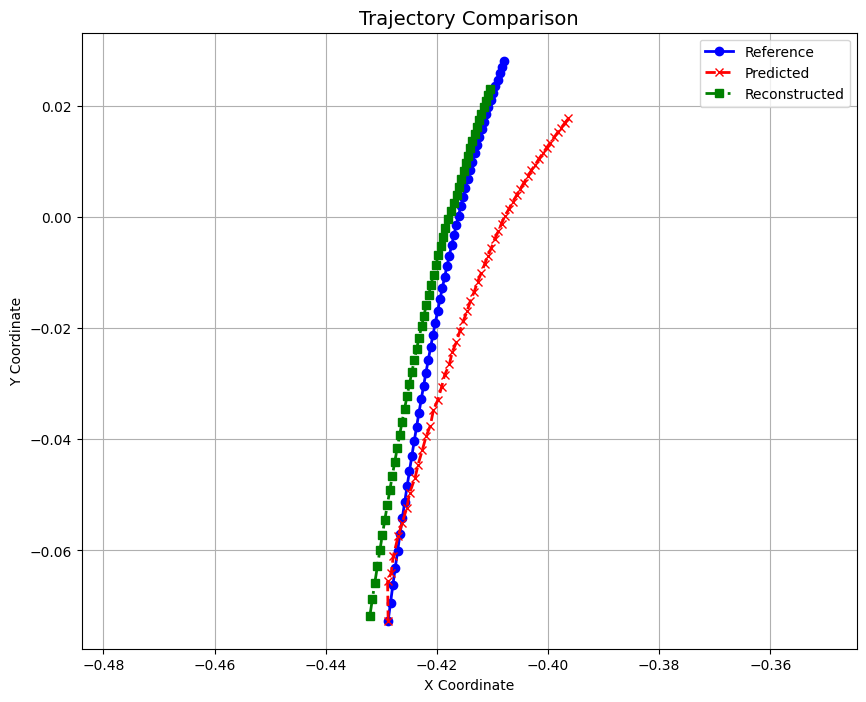

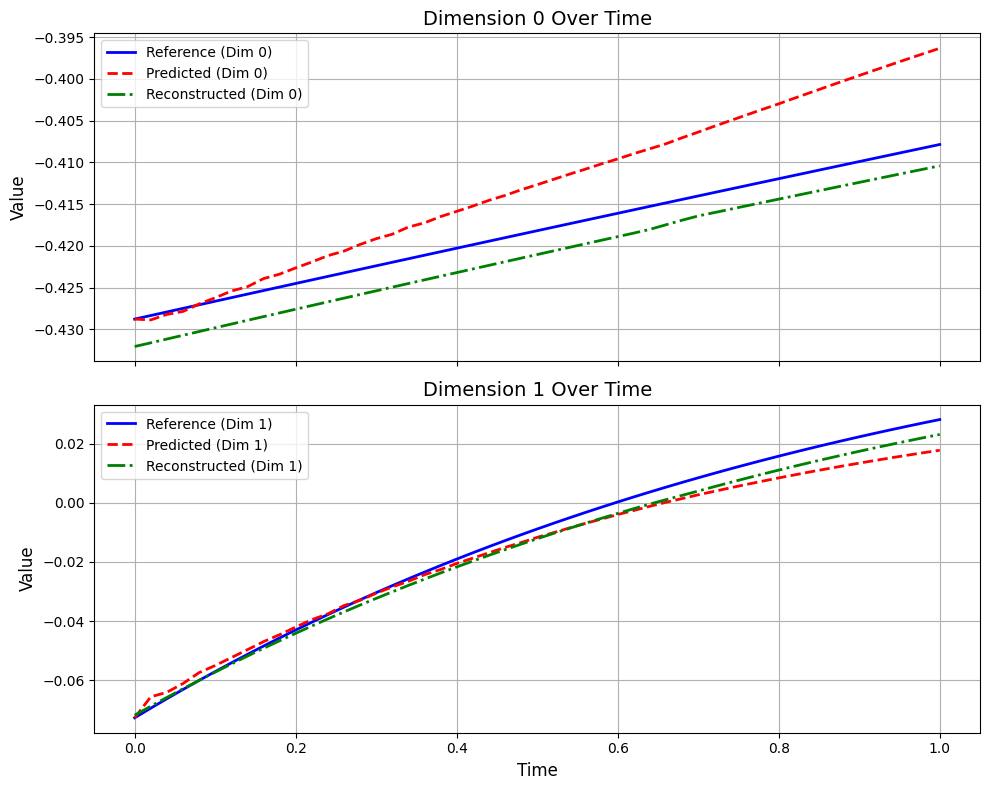

In [12]:
# Get a test sample
traj = preprocessed_data["Xtest"][5].to(device)

# Get reconstructed trajectory
model.eval()
with torch.no_grad():
    Y, reconstructed_traj = model.ae(traj)


# Get predicted trajectory
predicted_traj = trainer.predict_new(X0=traj[0], steps=len(traj)-1)

# Convert to numpy for plotting
traj = traj.cpu().detach().numpy()
reconstructed_traj = reconstructed_traj.cpu().detach().numpy()
predicted_traj = predicted_traj.cpu().detach().numpy()

# Plot trajectories
plot_trajectories(traj, predicted_traj, reconstructed_traj, folder_path=folder_path)
plot_trajectory_comparison(traj, predicted_traj, reconstructed_traj, folder_path=folder_path)

## Eigenvalues Visualization

Compute and visualize the eigenvalues of the Koopman operator on a unit circle.

Eigenvalues:
[ 0.99872   +0.j          0.9771603 +0.j          0.13493541+0.j
  0.11327809-0.63599634j  0.11327809+0.63599634j  0.090911  +0.20597522j
  0.090911  -0.20597522j  0.05287327+0.37585458j  0.05287327-0.37585458j
  0.03631443+0.j          0.02290853+0.51511997j  0.02290853-0.51511997j
 -0.06405182-0.268239j   -0.06405182+0.268239j   -0.06860781+0.07724521j
 -0.06860781-0.07724521j -0.07958506+0.5411289j  -0.07958506-0.5411289j
 -0.11091597+0.14352453j -0.11091597-0.14352453j -0.11785617-0.46711648j
 -0.11785617+0.46711648j -0.13088323+0.29865202j -0.13088323-0.29865202j
 -0.23105255+0.19206733j -0.23105255-0.19206733j -0.2936526 +0.8369619j
 -0.2936526 -0.8369619j  -0.31862348-0.5167563j  -0.31862348+0.5167563j
 -0.3392848 +0.28883985j -0.3392848 -0.28883985j -0.36808282+0.43471733j
 -0.36808282-0.43471733j -0.4138658 -0.12228587j -0.4138658 +0.12228587j
 -0.5346173 +0.08302876j -0.5346173 -0.08302876j -0.5393807 -0.66807544j
 -0.5393807 +0.66807544j -0.5646819 -0.28438473j 

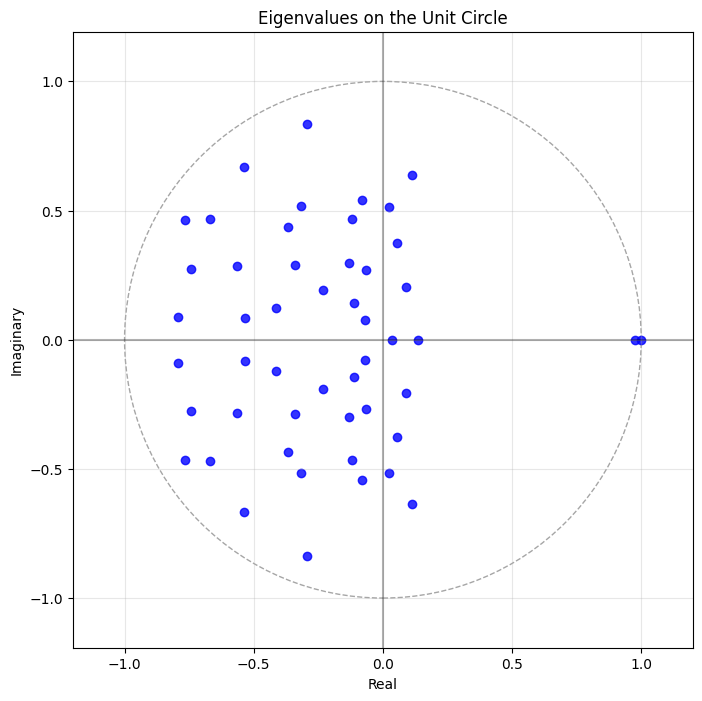

In [13]:
# Compute eigenvalues
eigenvalues, eigenvectors = torch.linalg.eig(model.knet.net.weight)
eigenvalues = eigenvalues.cpu().detach().numpy()
idx = np.argsort(eigenvalues.real)[::-1]
eigenvalues = eigenvalues[idx]

# Print eigenvalues
print('Eigenvalues:')
print(eigenvalues)

# Plot eigenvalues on unit circle
plot_eigenvalues_on_unit_circle(eigenvalues, folder_path)

print(f"Training and evaluation completed. Results saved in {folder_path}")

Reconstructed trajectory shape: torch.Size([500, 51, 2])
Original trajectory shape: torch.Size([500, 51, 2])


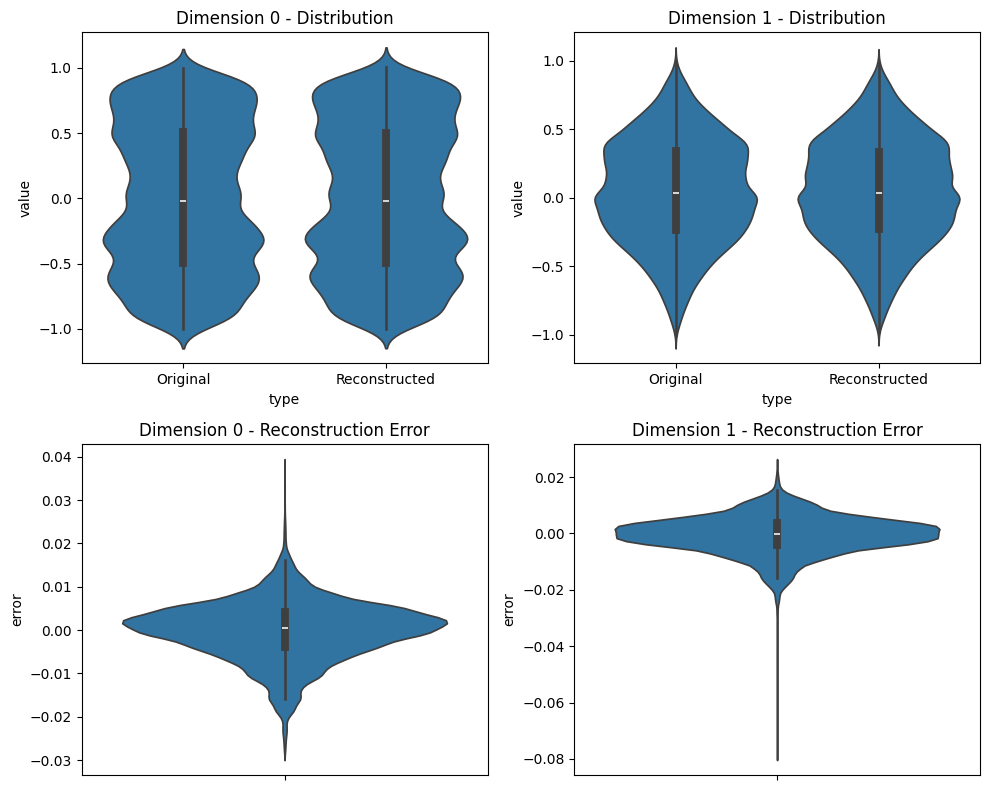

In [14]:
violin_plot(model, preprocessed_data["Xtest"], device, folder_path)